# Machine learning - predicting from rs-fMRI

In order to show how amazingly well `nilearn` is integrated into the `python ecosystem` for `neuroimaging` and `data science`, we will go through a more complex example analyses, outlining how `nilearn` can be used to `compute` `functional connectomes` which can then be used for `machine learning` analyzes in [scikit-learn](https://scikit-learn.org/stable/). Along the way we will also utilize other packages like [seaborn](https://seaborn.pydata.org/) for `visualization` to show you what's possible end-to-end and comparably few lines of `code`. 
For more information on the other packages we are using in this section, please consult the [prerequisites](https://peerherholz.github.io/workshop_IRTG2150/prerequisites.html) (e.g. [scikit-learn](https://peerherholz.github.io/workshop_IRTG2150/prerequisites/python_scikit.html) and [visualization](https://peerherholz.github.io/workshop_IRTG2150/prerequisites/python_visualization.html)). However, please note that all of these are super short introductions and that you should always consult the respective `documentation`.

Speaking of which, here's what we will be covering in this section:

1. Setup and Data
1. Extracting `times series` to build a `functional connectome`
1. `Machine learning` - preparation
1. `Machine learning` - running a model
1. `Machine learning` - adapting your pipeline

## Setup and Data

Before we start with anything, let's gather the important `functions` we need:

In [178]:
from glob import glob
import os
from nilearn import plotting, datasets, connectome
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from nilearn import image

If you intend to run a `machine learning` analyzes, there a lot of aspects you need to think about, like A LOT. While we will go through some of them here, we can't cover everything as this would be its own workshop or, more accurately, degree. However, we will address the basics. As visualized below, you need some `input` (`x`) (based on `samples` (`n`) by `features` (`p`)) for a `model` (`m`) to obtain some `output` (`y`) (which could be e.g. `classes` or `labels` depending on the analysis). 

Please note, that the topic of `machine learning` analyzes would be its own workshop and actually, degree. While we will do our best to outline important core aspects, we can't go through all that's needed given the time constraint. However, we encourage you to go through a different course we are running that is more focused on `machine learning` and `AI`, you can find it [here](https://peerherholz.github.io/Cog_Com_Neuro_ML_DL/introduction/notebooks/artificial_intelligence/terms_definitions.html).

![ml_overview](https://main-educational.github.io/brain_encoding_decoding/_images/decoding_pipeline_example.png)

Applied to `neuroimaging` or `neuroscientific research` more generally, the `input` (`x`) could be any sort of `MRI` data, for example `functional`/`structural images` or derived `measures` and the `output` (`y`) could be any sort of `measured`/`assigned` `variable` you would like to `predict`, for example, if `participants` belong to a certain `group`, a certain `behavioral score` (e.g. `clinical score` or `questionnaire score`), a `construct` or `percept`, etc. .

As mentioned above, here we will have a look at if we can use `functional connectome` `data` to `predict` certain `participant variables`. For other potential use cases, please consult the [nilearn documentation](https://nilearn.github.io/stable/_static/nilearn-transparent.png).

In more detail, we will use the `data` and `approaches` we explored in the [functional connectome section](https://peerherholz.github.io/workshop_IRTG2150/advanced/functional_connectivity.html) again to build upon already learned functionality and keep things holistic. In case you didn't take part in this section of the workshop or explore this independently, please go through this section first and then come back here as it outlines important aspects of the initial stages of the workflow.

As you might remember, we used a [`pre-processed` `dataset`](https://openneuro.org/datasets/ds000228/versions/1.0.0) from [Richardson et al. 2018](https://www.nature.com/articles/s41467-018-03399-2), entailing `data` from `155 participants` across different `age groups`(`3` to `12`) watching a `movie` while `resting-state fmri` data is collected. We can again simply get the `dataset` using [nilearn's dataset](https://nilearn.github.io/stable/modules/datasets.html) functionality. (If you already went through the [functional connectome section](https://peerherholz.github.io/workshop_IRTG2150/advanced/functional_connectivity.html), the `function` should automatically find the `dataset` and not `download` it, otherwise, it might take a couple of minutes.)

In [42]:
development_dataset = datasets.fetch_development_fmri()

[get_dataset_dir] Dataset found in /Users/peerherholz/nilearn_data/development_fmri

[get_dataset_dir] Dataset found in /Users/peerherholz/nilearn_data/development_fmri/development_fmri

[get_dataset_dir] Dataset found in /Users/peerherholz/nilearn_data/development_fmri/development_fmri

Through this, we get a rather comprehensive yet complex `dataset` which contains the following aspects:

In [43]:
development_dataset.keys()

dict_keys(['func', 'confounds', 'phenotypic', 'description'])

As you can see, we have `pre-processed functional images` (`func`), `confound regressors` (`confounds`), `demographic information` (`phenotypic`) and a `description` of the `dataset`. For now, we will focus on the `func` and `confounds`.

At first, we will use `nibabel`'s `nib-ls` to get a quick overview of the `pre-processed functional images`:

In [44]:
!nib-ls /Users/peerherholz/nilearn_data/development_fmri/*/*.nii.gz

/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar001_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz int8 [ 50,  59,  50, 168] 4.00x4.00x4.00x1.00
/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar002_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz int8 [ 50,  59,  50, 168] 4.00x4.00x4.00x1.00
/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar003_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz int8 [ 50,  59,  50, 168] 4.00x4.00x4.00x1.00
/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar004_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz int8 [ 50,  59,  50, 168] 4.00x4.00x4.00x1.00
/Users/peerherholz/nilearn_data/development_fmri/development_fmri/sub-pixar005_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz int8 [ 50,  59,  50, 168] 4.00x4.00x4.00x1.00
/Users/peerherholz/nilearn_data/development_fmri/development_fmri

We can easily see the `dimension` and `parameters` of the `pre-processed functional images` and that they're apparently consistent across `participants`, nice. 

For each `participant` we also have a `confound regressor` file, containing important `signal confounds` such `motion parameters`, `compcor components` and `mean signal` in `CSF`, `GM`, `WM`, Overal. Let's take a look at one of those `confound regressor` files:

In [45]:
import pandas as pd
confound_example = pd.read_table(development_dataset.confounds[0])
confound_example.head(n=10)

,trans_x,trans_y,trans_z,rot_x,rot_y,rot_z,framewise_displacement,a_comp_cor_00,a_comp_cor_01,a_comp_cor_02,a_comp_cor_03,a_comp_cor_04,a_comp_cor_05,csf,white_matter
0,-0.000233,-0.076885,0.062321,0.000732,0.000352,0.000841,0.000000,-0.099871,-0.007286,0.001780,-0.008073,0.030945,-0.022393,439.699409,451.645460
1,-0.006187,-0.078395,0.056773,0.000112,0.000187,0.000775,0.055543,-0.019437,-0.042308,0.016735,-0.012099,0.088777,-0.006171,439.471640,451.103437
2,-0.000227,-0.069893,0.083102,0.000143,0.000364,0.000716,0.054112,0.009096,-0.053206,-0.030388,-0.052925,0.019922,0.014776,439.744498,450.981505
3,0.002492,-0.074707,0.060337,0.000202,0.000818,0.000681,0.057667,0.060195,-0.083195,0.003578,-0.037011,0.026946,0.002505,440.772620,450.600261
4,-0.000226,-0.084204,0.085079,0.000183,0.000548,0.000682,0.051438,0.049833,-0.089819,-0.020825,-0.079329,0.008516,-0.000938,440.115442,450.678959
5,-0.000283,-0.049301,0.069010,0.000254,0.000564,0.001002,0.071359,0.026440,0.002005,0.010179,-0.099720,0.023749,0.079244,440.546828,451.134777
6,0.006253,-0.103812,0.062270,0.000630,0.000436,0.000849,0.100658,0.017215,-0.001337,-0.013313,-0.096449,-0.057687,-0.088844,439.971918,451.247543
7,0.005427,-0.029981,0.048102,0.000504,0.000288,0.000643,0.112807,-0.024674,0.090581,0.068727,-0.105057,0.086627,-0.024530,441.669121,451.663900
8,-0.000193,-0.102268,0.062353,0.001052,0.000511,0.000588,0.133473,0.009523,0.059368,-0.098649,-0.109783,-0.039773,-0.069773,441.075951,451.429633
9,-0.000187,-0.048240,0.062374,0.001055,0.000197,0.000588,0.069929,0.009358,0.080471,0.116457,-0.096985,0.010961,0.037194,441.081689,451.276734


Using a little bit of `matplotlib` and `seaborn`, we can also easily `plot` the `confound regressors`, for example the `motion regressors`, ie `translation` and `rotation`:

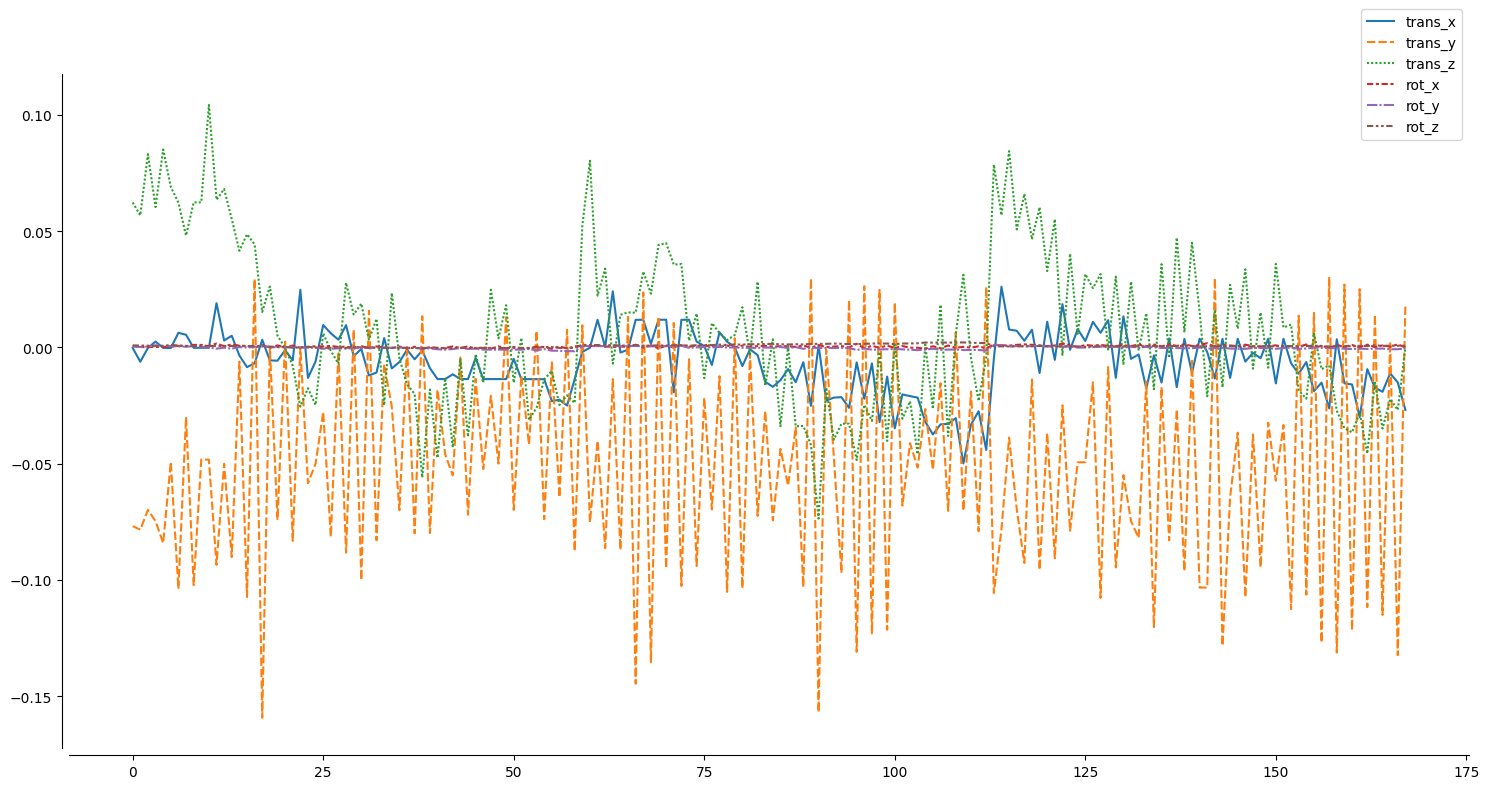

In [46]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(15,8))
ax = sns.lineplot(data=confound_example[confound_example.columns[:6]])
sns.despine(offset=5)
sns.move_legend(ax, "center right", bbox_to_anchor=(1, 1))
plt.tight_layout()

With everything in-place and ready to go, we can start exploring how to use `functional connectivity` for `machine learning` analyzes via `nilearn` and `scikit-learn`! 

## Machine learning - preparation

Looking back at the graphic above and given that we want to run a `supervised` `machine learning` analysis, we need to prepare the `input` (`x`) and `output` (`y`). We will do so in two respective sub-sections.

### The `input` - `X`

As mentioned before, we want to use `functional connectomes` as `input` (`x`) for our `machine learning` `model` (`m`). In other words, we need to obtain a `sample` (`n`) by `feature` (`p`) `matrix`. Applied to our `data` and `planned analyzes`, this means we need to get a `functional connectom` (our `features` (`p`)) for all `participants` (`samples` (`n`)) in the `dataset`.

If you already went through the [functional connectome section](https://peerherholz.github.io/workshop_IRTG2150/advanced/functional_connectivity.html), you should have this ready to go and can load the needed data via:

In [47]:
X_features = np.load('data/development_fmri_correlation_matrix.npz', allow_pickle=True)['correlation_matrices']

If you didn't go through the [functional connectome section](https://peerherholz.github.io/workshop_IRTG2150/advanced/functional_connectivity.html), you need to `compute` the `functional connectomes` for all `participants` now. Please implement your solution below based on the content in the other `section`, making the `output` a `numpy array` with a `shape` of `(155, 39, 39)`, naming it `X_features` and keep in mind that it might take a couple of minutes:

In [48]:
## please provide your solution here

This should get you a `numpy array` including a `functional connectome` (`39` `regions`) for each of the `participants` (`155`).

In [49]:
X_features.shape

(155, 39, 39)

We can also use `nilearn` to quickly make sure, things look as expected. For example, here's the `functional connectome` of the first `participant`.

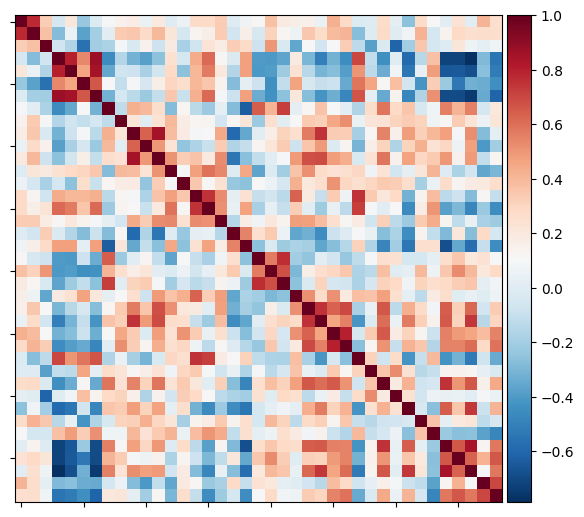

In [50]:
plotting.plot_matrix(X_features[0])

Looks about right, nice. 

However, this actually outlines a potential problem with our `input` (`X`): as you can see and most likely already knew, the `functional connectome` is a `symmetric matrix` and thus its `values` and in turn our `features` (`p`) are mirrored and therefore duplicated across the `diagonal`. This would introduce a potential `bias` and `error` we need to address. 

Luckily, we can easily do that by extracting the `lower` or `upper` `triangle` of the `matrix` using `nilearn` and thus cut the `features` in half, getting only the `unique` ones.

In [51]:
features_participant = connectome.sym_matrix_to_vec(X_features[0], discard_diagonal=True)

With that, we get the `values` of the `lower triangle` of the `symmetric matrix` (`functional connectome`), discarding the `diagnoal` (which we don't need given its the `correlation` of a `region` with itself).

In [52]:
features_participant.shape

(741,)

This gets us `741` `unique values`, ie `features`. However, we would of course need to do that for all `participants`. Thus, could you please implement a little `for-loop` to do so, overwriting the `X_features variable` at the end?

In [53]:
## please provide your solution here

In [54]:
features_unique = []

for i, matrix in enumerate(X_features):

    features_unique_tmp = connectome.sym_matrix_to_vec(matrix, discard_diagonal=True)

    features_unique.append(features_unique_tmp)

X_features = np.array(features_unique)

Let's make sure the `output` is as expected:

In [55]:
X_features.shape

(155, 741)

Great, we now have a `numpy array` containing the `unique values`, ie `features` (`p`), (`741`) for each `participant` (`155`). 
To get a better idea of this looks like, we can easily `visualize` our `X`, that is `samples` (`n`) by `feature` (`p`) `matrix`.

Text(0, 0.5, 'samples (n) - participants')

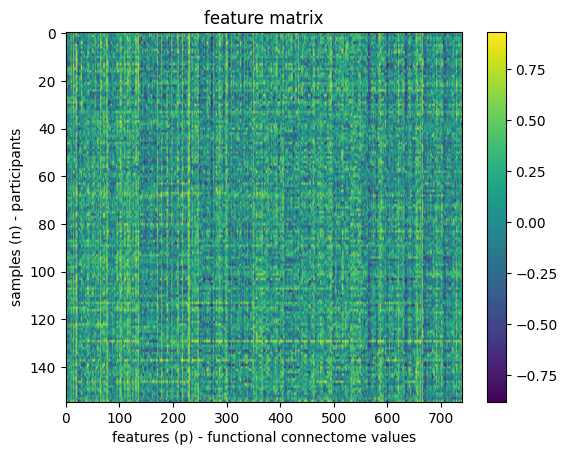

In [56]:
plt.imshow(X_features, aspect='auto', cmap='viridis')
plt.colorbar()
plt.title('feature matrix')
plt.xlabel('features (p) - functional connectome values')
plt.ylabel('samples (n) - participants')

Awesome, we now have our `input`, ie `X`, ready and with that one part of the requirements we outlined above. Now to the other part.

### The output - y

In the beginning of this `section`, we mentioned that we are running a `supervised machine learning` analysis and thus also need the `labels` of the outcome we want to `predict`. In more detail, given that we want to `predict` something for each of our `samples` (`n`) based on their respective `features` (`p`) within a `supervised learning` approach, we need a way to assess if the `predictions` are accurate/correct and if not, how far they're off, that is assessing the `performance` or `accuracy` of the `model`. This also concerns the `model`s `generalizability`, `error pattern` and so forth.  

![supervised_unsupervised](https://raw.githubusercontent.com/PeerHerholz/ML-DL_workshop_SynAGE/master/lecture/static/supervised_unsupervised.png)


In a `supervised learning` approach we therefore have to provide the ("ground-") truth `labels` for each `sample` (`n`) against which we can compare the `prediction` against. Depending on your specific `data` and analyses this can be many different things and you might get the `labels` from different places. Given that we want to `predict` certain `demographic variables` of the `participants`, we should have a look at the `dataset`s [participant.tsv](https://bids-specification.readthedocs.io/en/stable/modality-agnostic-files.html#participants-file) which in a [BIDS]() dataset contains all `demographic` information for all `participants`, including common ones, such as `age`, and more specific ones, such as `questionnaire responses`.

Thus, lets have a look at the `participant.tsv` file of our example `dataset`:

In [57]:
demographic_info = pd.DataFrame(development_dataset.phenotypic)
demographic_info.head()

,participant_id,Age,AgeGroup,Child_Adult,Gender,Handedness
0,sub-pixar123,27.06,Adult,adult,F,R
1,sub-pixar124,33.44,Adult,adult,M,R
2,sub-pixar125,31.00,Adult,adult,M,R
3,sub-pixar126,19.00,Adult,adult,F,R
4,sub-pixar127,23.00,Adult,adult,F,R


Already looks great but it might be nice to have a bit more information, specifically, `behavior`ally-relevant `questionnaire data`. Luckily, we have that information too. However, it's in a different version of the `participants.tsv` which is not included in the `nilearn` version of the `dataset`. No worries though, as with `python` this is easily addressed as we can simply download the version we need and overwrite the existing one (thus also showing you once again how versatile `python` is). Please note, that we're doing this is a showcase here and you shouldn't overwrite important files like this one within a given analysis or if you need to for whatever reason, explicitely mention it in the `code`.

Downloading files via `python` can be done in many ways but most likely the in-built [urllib](https://docs.python.org/3/library/urllib.html) package does the trick. We simply need to define a `url` to the file we want to `download` and where to `download` it to.

In [58]:
# import urllib
import urllib.request

# define a path and filename under which we want to store the to-be-downloaded file
demographic_info_path = datasets.get_data_dirs()[0] + '/development_fmri/development_fmri/participants.tsv'

# define the url from which we want to download the file
url = 'https://drive.usercontent.google.com/u/0/uc?id=1Y4zGVuo7EIU89Cu3JYrt6svgr5Y5oR14&export=download'

# download the file
urllib.request.urlretrieve(url, demographic_info_path)


('/Users/peerherholz/nilearn_data/development_fmri/development_fmri/participants.tsv',
 <http.client.HTTPMessage at 0x124f99150>)

Ok, let's check if this worked as intended by re-`load`ing the `participants.tsv` file.

In [59]:
demographic_info = pd.read_csv(demographic_info_path, sep='\t').sort_values('participant_id')
demographic_info.head()

,participant_id,Age,AgeGroup,Child_Adult,Gender,Handedness,ToM Booklet-Matched,ToM Booklet-Matched-NOFB,FB_Composite,FB_Group,WPPSI BD raw,WPPSI BD scaled,KBIT_raw,KBIT_standard,DCCS Summary,Scanlog: Scanner,Scanlog: Coil,Scanlog: Voxel slize,Scanlog: Slice Gap
0,sub-pixar001,4.774812,4yo,child,M,R,0.80,0.736842,6.0,pass,22.0,13.0,NaN,NaN,3.0,3T1,7-8yo 32ch,3mm iso,0.1
1,sub-pixar002,4.856947,4yo,child,F,R,0.72,0.736842,4.0,inc,18.0,9.0,NaN,NaN,2.0,3T1,7-8yo 32ch,3mm iso,0.1
2,sub-pixar003,4.153320,4yo,child,F,R,0.44,0.421053,3.0,inc,15.0,9.0,NaN,NaN,3.0,3T1,7-8yo 32ch,3mm iso,0.1
3,sub-pixar004,4.473648,4yo,child,F,R,0.64,0.736842,2.0,fail,17.0,10.0,NaN,NaN,3.0,3T1,7-8yo 32ch,3mm iso,0.2
4,sub-pixar005,4.837782,4yo,child,F,R,0.60,0.578947,4.0,inc,13.0,5.0,NaN,NaN,2.0,3T1,7-8yo 32ch,3mm iso,0.2


Fantastic! Now we have many interesting `behavior`ally-relevant `variables` we could include in our `machine learning` analysis.

We will start with using `Age` as a `variable` of interest, ie our `labels` as we want to evaluate if we can `predict` the `age` of `participant`s based on their `functional connectome`. (Please note, that this is an example to showcase functionality and might not reflect a sensible analysis. However, given our example, a lot of prior research actually used different `neuroimaging` `data` to `predict` `age`.)

For easy access, we will `assign` the `age` of `participants`, ie our `labels` to a new `python` `variable`.

In [60]:
y_age = demographic_info['Age']

One of the first things you should always do, independent of the planned analyzes, is to look at your `data` as it more often than not already includes a lot of information and might even point to potential problems and/or requirement/possibility for one approach over another. Therefore, we should `plot` our `labels` to get a respective idea. 

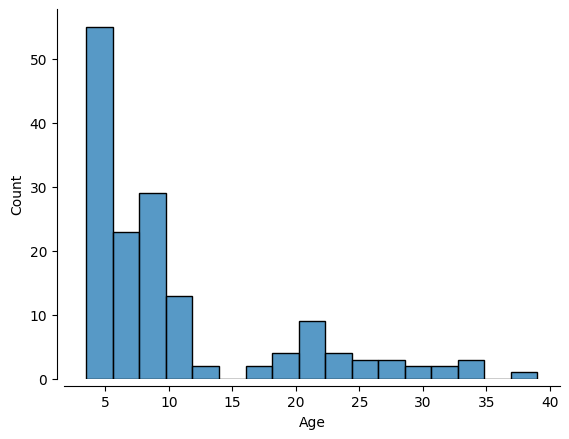

In [61]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.histplot(y_age)
sns.despine(offset=5)

Based on this outcome and our planned analysis of `predict`ing `age` given `functional connectomes`: what do you think? Is there any problem here? (Please don't scroll down to get the answer hehe.)

With that, we have concluded our `data` preparation (getting our `input` `X`, `features` (`p`) by `samples` (`n`), and `output` (`y`), the `labels`) and have it ready to go.

## Machine learning - running a model

Having the `data` ready, the next thing you should do, is to `split` your `dataset` into a `training` and a `test` `sample`. We will explore this further in a bit. 

However, as seen and discussed above, there's a tremendous `imbalance` concerning the `distribution` of our `variable` of interest, ie `labels`. That is, there are way more `samples` for certain `age` ranges than others.  In turn, your `machine learning` `model` (`m`) would "see" way more `data` for certain `age` ranges than others which could and most likely will introduce all sorts of problems concerning `performance`, `generalizability` and so on.

Furthermore, it is part of a more general problem. “Classical” `machine learning` `models` and the underlying `algorithms` operate on the assumption that there are more `samples` (`n`) than there are predictors or `features`(`p`). In fact many more. Why is that?  
Consider a `high-dimensional space` whose `dimensions` are defined by the number of `features` (e.g. `10 features` would result in a `space` with `10 dimensions`. The resulting `volume` of this `space` is the amount of `samples` that could be drawn from the `domain` and the number of `samples` entails the `samples` you need to address your `learning problem`, ie outcome. That is why folks say: “get more `data`”, `machine learning` is `data`-hungry: our `sample`s need to be as `representative` of the `high-dimensional domain` as possible.  
Thus, as the number of `features` increases, so should the number of `samples` as to capture enough of the `space` for the `model` at hand.

This is referred to as the [curse of dimensionality](https://en.wikipedia.org/wiki/Curse_of_dimensionality) and poses as a major problem in many fields that aim to utilize `machine learning` on unsuitable data. Why is that?  
Just imagine we have way more `features` than `samples`, ie `50 features` and `10 samples`. Instead of having a large amount of `samples` within the `space`, allowing to achieve a sufficient coverage of the latter, we now have a very `high-dimensional space` (`50 dimensions`) and only very few `samples` therein, basically not allowing us to capture nearly enough of the `space` as we would need to. This can result in unexpected outcomes, misleading results or even lead to complete `model` failure. Furthermore, respective `datasets` often lead to `models` that are `overfitted` and don’t `generalize` well.

However, there are a few things that can be done to address this, including `feature selection`, projection into `lower-dimensional spaces` (via `dimensionality reduction` approaches) or `representations` or `regularization`.

Question for everyone: what kind have datasets do we usually have in neuroscience, especially `neuroimaging`?

After everything we just talked about, we want to be sure that our `training` and `test` `sample` are as closely matched as possible! We can do that with a so-called "`stratified split`". The `dataset` at hand has a `variable` indicating `AgeGroup` which we could use for that. We can use that to make sure our `training` and `testing` sets are balanced!

In [62]:
age_class = demographic_info['AgeGroup']
age_class.value_counts()

AgeGroup
5yo       34
8-12yo    34
Adult     33
7yo       23
3yo       17
4yo       14
Name: count, dtype: int64

With that, we can finally create the `training` and `test` `samples`or `sets`. We of course don't have to do this by hand but can use a helpful function from [scikit-learn](https://scikit-learn.org/stable/), namely [train_test_split](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html#sklearn.model_selection.train_test_split), which will do that for us given we provide the needed information.

In [63]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test= train_test_split(X_features, # x
                                                   y_age, # y
                                                   test_size = 0.2, # 80%/20% split  
                                                   shuffle = True, # shuffle dataset
                                                                    # before splitting
                                                   stratify = age_class,  # keep
                                                                           # distribution
                                                                           # of ageclass
                                                                           # consistent
                                                                           # betw. train
                                                                           # & test sets.
                                                   random_state = 123 # same shuffle each
                                                                       # time
                                                                       )

We know: there's a lot going on. So let's unpack it. We're using `train_test_split` to `split` our `data` into `training` and `test` `samples` or `sets`. For this we:

- provide the `input`, `X` (`samples` (`n`) by `features` (`p`))
- the `labels`, `y`
- set the test size to `0.2` to create a `80/20` split which was shown to be a sensible default by [Varoquaux et al. 2017](https://scholar.google.com/scholar_url?url=https://www.sciencedirect.com/science/article/pii/S105381191630595X%3Fcasa_token%3D3ZLhz-dCYC4AAAAA:JGnWJsbPFIiEx0AD7j-GUVvz_VmLlIvwSuf70CQ4C4lBp84QRUWvQ83IpkVevRxfTO4gth9Fhcs&hl=en&sa=T&oi=gsb-ggp&ct=res&cd=0&d=10295908634968793952&ei=uxvHZ9H3FeehieoP9KefoQg&scisig=AFWwaea61Pn_LBOcXSCrZsrl7IhU)
- set `shuffle` to `True` to `shuffle` the `dataset` before `splitting` it
- set `stratify` to `age_class` to create a `stratified split` of our `dataset`, ensuring equal distribution of `labels`
- set the `random_state` to `123` to make our analysis `reproducible` (as we `randomly` `shuffle` the `data` and draw `samples`, we would like to "control" the `randomness` a little bit) 

As an output we get:

- `X_train` -> the `training set` of our `input` `X`
- `X_val` -> the `validation set` of our `input` `X`
- `y_train` -> the `training set` of our `labels` `y`
- `y_val` -> the `validation set` of our `labels` `y`

Let's have a closer look at them, starting with the number of `samples` for each.

In [64]:
print('training:', len(X_train),
      'testing:', len(X_test))

training: 124 testing: 31


We get `124` `samples`, ie `participants` in the `training sample` and `31` `samples`, ie `participants` in the `test sample`.
Next, we also want to make sure the `stratification` based on `age` worked. To do so, we could plot their respective `distributions` in the `training` and `test` `set`.

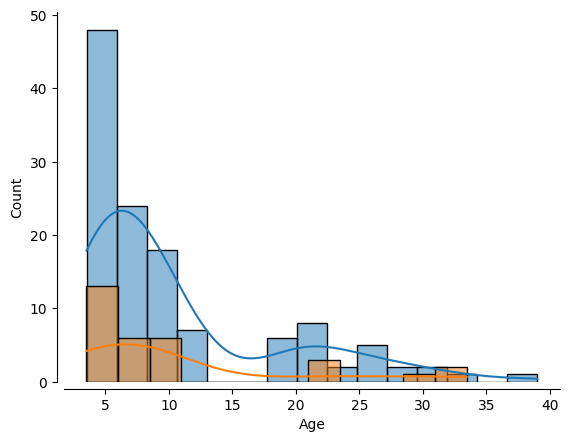

In [65]:
sns.histplot(y_train, kde=True)
sns.histplot(y_test, kde=True)
sns.despine(offset=5)

How would you assess this outcome? Do we have a somewhat comparable `distribution` of `labels` in the `training` and `test` `set`?

Alrighty, we have everything set: `X`, `y` and a `stratified split` between `training` and `test` `set` based on `age`.  
Now, it's finally time to specify and run a `machine learning` `model`. But the question is: what kind? We know that we want to run a `supervised learning` approach. That's the first big question. Another one is: what do we want to `predict`?

The outcome, ie the `labels` or `y`, specifically their `data type`. Here's a hopefully helpful graphic to explain this further:

![supervised_unsupervised_outcome](https://raw.githubusercontent.com/PeerHerholz/ML-DL_workshop_SynAGE/master/lecture/static/learning_problems_task_types.png)


Given that we want to `predict` the `age` of `participants` based on their `functional connectome`, we are dealing with a `continuous problem`, as `age` is a `continuous variable`. So, we should look within this quadrant.

While this may seem unambitious, simple models can be and often are very robust. And we probably don't have enough `data` to create more complex `models` (but we can try later).

For more information, see this excellent resource:
https://hal.inria.fr/hal-01824205

Lucky for us, `scikit-learn` has us covered as there's a respective `class` for most `models` you would like to run.

![supervised_unsupervised_outcome_scikit_learn](https://raw.githubusercontent.com/PeerHerholz/ML-DL_workshop_SynAGE/master/lecture/static/sklearn_map_task_type.png)


Importantely, this graphic also outlines the need for `large-scale dataset`s again. 

For the sake of simplicity and time, we will employ a `model` that is somewhat unfeasible. `Machine learning` can get pretty "fancy", ie complex, pretty quickly. We'll thus start with a fairly standard `regression model`, a so-called `Support Vector Regressor (SVR)` with a `linear kernel`. 

In [66]:
from sklearn.svm import SVR

l_svr = SVR(kernel='linear')

Comparable to the different aspects we have explored in `nilearn`, after setting up a `model`, we need to `fit` it to the `data`. Importantely, we will do so on the `training` `set` only.

In [179]:
l_svr.fit(X_train, y_train)

SVR(kernel='linear')

After that, we can already go to the next step and `predict` the `labels` based on what the `model` learned. The `fit`ted `model` `l_svr` allows us to do that easily by calling its `predict` function.

In [68]:
y_pred = l_svr.predict(X_train) 

Cool. Now, we can also use `l_svr` to `compute` the `performance` of the `model` via its `score` function. The respective value is based on the `model` and `learning problem` at hand, the `score` function returns `values` that can reflect different things. As we're working with `continuous` `data` (`age`) and using a corresponding `model` (`SVR`), the output will in our case reflect `r squared` or `R²`.

In terms of the workflow we outlined earlier, we are now talking about the `metric` that is used to evaluate the `model`.

![ml_overview](https://main-educational.github.io/brain_encoding_decoding/_images/decoding_pipeline_example.png)


`R-squared` (`R²`) is a common `metric` for `regression models` that indicates how much of the `variability` in the `target variable` is `explained` by the `model`. Formally, it compares the `model`’s `predictions` to a simple baseline (using the `mean` of the `target`) to see if the `model` does a better job `predicting` the `target values` than just guessing their `average`. A higher `R²` (closer to `1`) usually suggests a better `fit`, while lower or `negative values` suggest the `model` isn’t capturing the underlying `patterns` as well as the baseline.

In [69]:
r2 = l_svr.score(X_train, y_train) 

Having `fit`ted and `score`d our `model` we can now evaluate its `performance` by checking its `accuracy` and plotting `predicted` against actual `labels` (as we are using on a `supervised learning` approach). 

accuracy (R2) 0.9998390672291223


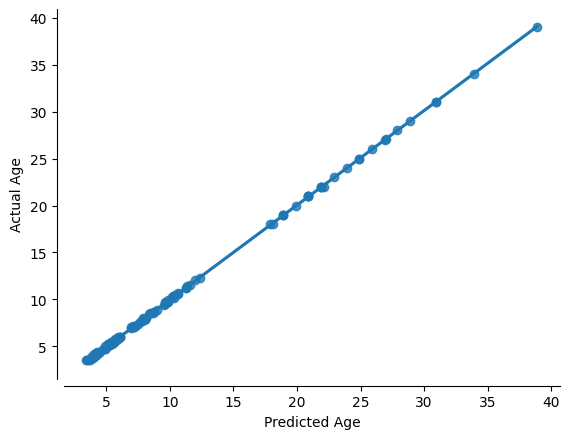

In [70]:
# print results
print('accuracy (R2)', r2)

sns.regplot(x = y_pred, y = y_train)
plt.xlabel('Predicted Age')
plt.ylabel('Actual Age')
sns.despine(offset=5)

Oh damn, the hype is true: `machine learning` is amazing!!! Almost a perfect fit!

...which usually means there's something wrong. What's the problem here?

That's correct: we evaluated the `model` `predictive` `performance` on the same `data` we used to `train` it. This is not valid as the `model` has already "seen" and thus knows the `data` it should `predict`. To evaluate its `predictive` and overall `performance`, we need to `validate` it on previously unseen, ie new, `data`. If we assess the `model` on the same `data` it was `train`ed on, it may simply `memorize` `patterns` rather than `generalize` to new `data`. By using a separate `validation` `set`, we can measure how well the `model` performs on unseen `data` and `fine-tune` it accordingly.  In turn, this means that we should split our `training` `set` again, this time into a `training` and `validate` `set`. Importantly, this still concerns the `training` of the `model` as the final evaluation will happen through the `test` `set`, ie `data` that was not seen during any part of the `model` `training`. 

That being said, let's `split` the `training` `set` again into a `training` and `validation` `set`. For this, we can use the `train_test_split` again. However, this time only applying it on the `training` `set`.

In [71]:
age_class2 = demographic_info.loc[y_train.index,'AgeGroup']

X_train_train, X_val, y_train_train, y_val = train_test_split(
                                                    X_train, # x
                                                    y_train, # y
                                                    test_size = 0.25, # 75%/25% split  
                                                    shuffle = True, # shuffle dataset
                                                                    # before splitting
                                                    stratify = age_class2,  # keep
                                                                           # distribution
                                                                           # of ageclass
                                                                           # consistent
                                                                           # betw. train
                                                                           # & test sets.
                                                    random_state = 123 # same shuffle each
                                                                       # time
                                                                       )

How does our newly `split`ted `training` `set` look now?

In [72]:
print('training:', len(X_train_train),
      'testing:', len(X_val))

training: 93 testing: 31


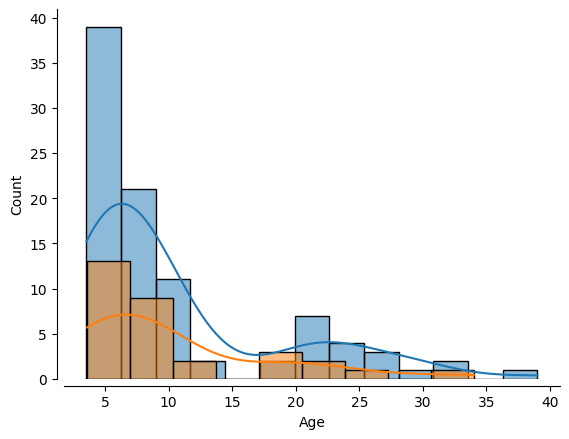

In [73]:
sns.histplot(y_train_train, kde=True)
sns.histplot(y_val, kde=True)
sns.despine(offset=5)

Great, this looks about right. Now let's `run` our `model` again but this in the correct manner. That is we `fit` it as before but on the `training` `set` of the `training` `set`:

In [180]:
l_svr.fit(X_train_train, y_train_train)

SVR(kernel='linear')

and then use the `fit`ted `model` to `predict` our outcome of interest, ie `age`, based on previously unseen `data`, that is the `validation` `set` of the `training` `set`.

In [75]:
y_pred = l_svr.predict(X_val) 

How does the `model` `perform`? Let's have a look!

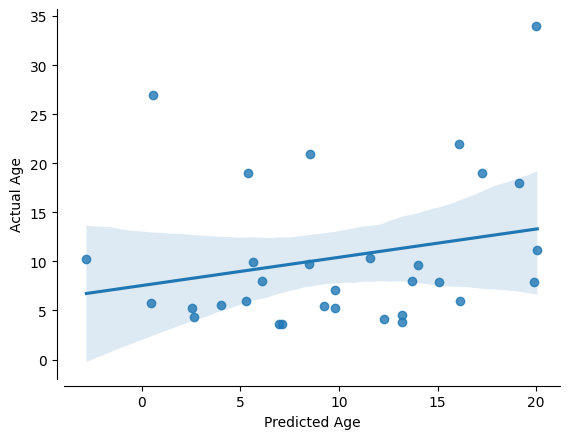

In [76]:
sns.regplot(x = y_pred, y = y_val)
plt.xlabel('Predicted Age')
plt.ylabel('Actual Age')
sns.despine(offset=5)

Oh damn, that seems way worse than before. We should put some numbers to that, ie assessing the `model`'s `performance` as before.

In [38]:
acc = l_svr.score(X_test, y_test) 
print('accuracy (R2) = ', acc)

accuracy (R2) =  0.1460991511206282


There you see `bias` and `overfitting` in action. It seems that our `model` is not able to `generalize` to previously `unseen` `data`. To put this into a more intelligable perspective, we will `compute` another assessment of our `model`'s `performance`. Specifically, we’ll also have a look at the [mean-absolute-error (MAE)](https://en.wikipedia.org/wiki/Mean_absolute_error). It is measured as the `average sum` of the `absolute diffrences` between `predictions` and `actual` observations, ie `labels`. Unlike other `measures`, `MAE` is more robust to outliers, since it doesn’t square the deviations (cf. [mean-squared-error](https://en.wikipedia.org/wiki/Mean_squared_error)). It provides a way to asses “how far off” are our `predictions` from our `actual data`, while staying on it’s referential space.

In [78]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_true=y_val,y_pred=y_pred)

print('MAE = ',mae)

MAE =  6.495359210136806


As the `MAE` based on the `absolute difference`s in terms of `labels`, its `unit` reflects the `unit` of the `labels`. In our case this would refer to `age` in `years`. In turn, our `model`'s `predictions` are on `average` `6.5 years` off. This might not seem like a lot but might be crucial depending on the `data`, `learning problem` and intended `use`.

So ... maybe `machine learning` isn't as amazing as we thought...

However, here's the "good news". Only `split`ting the `training data` once can lead to `performance` estimates that are highly dependent on that particular `split`, which might not represent the overall `variability` of the `data`. This approach risks `overfitting` to one `subset` of `data` and may produce misleading conclusions about a `model`'s ability to `generalize`. Additionally, `partitioning` the available `data` into three `sets`, we drastically reduce the number of `samples` which can be used for `learning`.

To address this, `cross-validation` is utilized: it repeatedly partitions the `data` into different `training` and `validation sets`. `Cross-validation` is important because it provides a more `robust` and `reliable` estimate of a `model`'s `performance`. By partitioning the `data` into multiple `subsets` (`folds`) and iteratively `training` and `validating` on different `splits`, we can ensure that the `performance metrics` are not dependent on a single arbitrary `train-validation` `split`. This process helps in `tuning` `hyperparameters`, selecting the best `model`, and reducing the risk of `overfitting` by `validating` the `model`'s ability to `generalize` to unseen `data`.

While we could implement this manually, e.g. via a `for loop`, we can make things easier and more straightforward by utilizing `scikit-learn`'s [cross_val_predict](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_val_predict.html#sklearn.model_selection.cross_val_predict) and [cross_val_score](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_val_score.html#sklearn.model_selection.cross_val_score) function.

As you can see below, they basically include the `model`, the `training set` and an `argument`, `cv` that allows us to specify how the `cross-validation` should be implemented. No need to manually `split` the `training set` again, the `cross_val_` functions will handle that for us based on the `data` and `cv`. Regarding the latter, we will simply use `10` to indicate that we want to `split` the `data` into `training` and `validation` `10` times, each time `training` the `model` and `evaluating` its `performance`. Please note, that there are way more complex `cv` settings.

We will start with `cross_val_predict` to get `prediction` based on `repeated` `splits`.

In [84]:
from sklearn.model_selection import cross_val_predict

y_pred = cross_val_predict(l_svr, X_train, y_train, cv=10)


Now, `y_pred` reflects the average `prediction` across `10` different `splits` of the `training data` into `training` and `validation` sets. Thus, we can plot it as before.

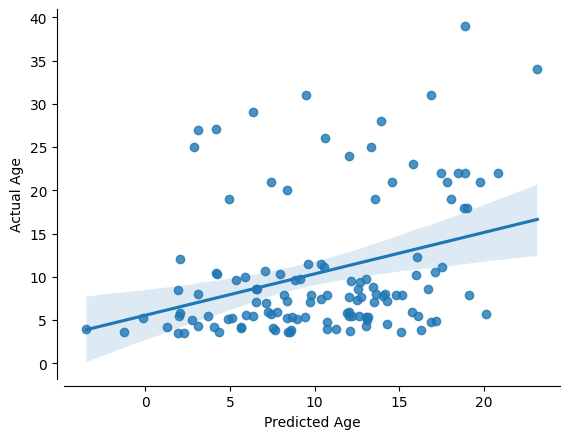

In [85]:
sns.regplot(x = y_pred, y = y_train)
plt.xlabel('Predicted Age')
plt.ylabel('Actual Age')
sns.despine(offset=5)

Ok ok, this looks slightly "better". However, we need the numbers! Thus, let's use `cross_val_score`.

In [94]:
from sklearn.model_selection import cross_val_score

acc = cross_val_score(l_svr, X_train, y_train, cv=10)
mae = cross_val_score(l_svr, X_train, y_train, cv=10, scoring='neg_mean_absolute_error')

With that, we can look at the `performance` of the `predictions` for each `fold` of the `cross-validation`.

In [95]:
for i in range(10):
    print('Fold {} -- R2 = {}, MAE = {}'.format(i, acc[i],-mae[i]))

Fold 0 -- R2 = -0.2162934689236784, MAE = 7.537528165271434
Fold 1 -- R2 = -0.13872475721392274, MAE = 5.960973887258287
Fold 2 -- R2 = 0.08720732875204673, MAE = 5.129654374881498
Fold 3 -- R2 = 0.20517790443178285, MAE = 6.027738913670467
Fold 4 -- R2 = -0.07324580326043417, MAE = 5.013468449712502
Fold 5 -- R2 = -0.2985025699694268, MAE = 6.907882686510539
Fold 6 -- R2 = 0.03402841212143537, MAE = 5.425388417768737
Fold 7 -- R2 = 0.2993194235898986, MAE = 5.2339398953244896
Fold 8 -- R2 = 0.22097275083179524, MAE = 5.780136195014447
Fold 9 -- R2 = -0.6907718986801099, MAE = 7.1681001463488


We can also look at the overall `performance` of the `model`.

In [96]:
print('R2:',acc.mean())
print('MAE:',mae.mean())

R2: -0.05708326783206132
MAE: -6.0184811131761204


Not that much better but more importantly, this is a more accurate estimation of our `model`'s `predictive` efficacy. Our `sample size` is larger based on several rounds of `prediction` of `unseen data` through `repeated splits` of the `training data`. 

So, where can we go from here? While the above-outlined steps are somewhat realistic and entail sane defaults, `machine learning` is far more complex and includes many more aspects. In the following, we will explore a few of them.

## Machine learning - adapting your pipeline

It's very important to learn when and where its appropriate to apdat your `machine learning` pipeline. Since we have done all of the previous analysis in our `training data`, we could go through a few different commonly utilized approaches. But we **absolutely cannot** "test" it on our left out `test` `data`. If we do, we are in great danger of `overfitting` and introducing biases.

It is not uncommon and overall ok to try other `models`, or adapt the pipeline in other ways. The important part is: don't go on a wild goose chase to try to find the best possible outcomes. Everything you do should still be based on valid `assumptions`/`estimates`, your `data` and `learning problem`. In the case at hand, due to our relatively small `sample size`, we are probably not powered sufficiently to do so, and we would once again risk `overfitting`. However, for the sake of demonstration, we will do some adapting. 

![ml_overview](https://main-educational.github.io/brain_encoding_decoding/_images/decoding_pipeline_example.png)


We will try a few different examples:
* `Normalizing` our `target data`
* Tweaking our `hyperparameters`
* Trying a more complicated `model`
* `Feature selection`

### Normalizing the target data

`Normalizing` the `target variable`, ie `labels` can be particularly useful when the `target values` vary widely in `scale` or are `skewed`. `Scaling` the `target` helps stabilize and speed up the `optimization process` during `training`, as the `model` deals with `values` within a more manageable `range`. This can lead to improved `numerical stability`, more efficient `convergence`, and sometimes even enhanced `predictive accuracy`, especially when using `algorithms` sensitive to the `scale` of the `data`. However, as mentioned before, please make sure this is applicable to your `data`.

In `scikit-learn`, we use the [preprocessing](https://scikit-learn.org/stable/api/sklearn.preprocessing.html#module-sklearn.preprocessing) methods to employ a vast range of approaches to change raw `feature vectors` into a `representation` that is more suitable for the downstream `estimators`, ie `models`. More on that is outlined in the [preprocessing section](https://scikit-learn.org/stable/modules/preprocessing.html#preprocessing) of the documentation.

`Normalization` is a `preprocessing` technique that `transforms` `features` to a `common scale`, without distorting differences in the `ranges` of `values`. This process is especially important when `features` have different `scales` or `units`, as it prevents `features` with larger `magnitudes` from dominating those with smaller `scales`. Common `normalization methods` include `min-max scaling` (which `rescale`s `features` to a fixed `range`, typically `[0, 1]`) and `standardization` (which centers data by subtracting the `mean` and `scales` it by the `standard deviation`). By `normalizing` the `data`, `machine learning` algorithms — particularly those that rely on `distance calculations` or `gradient-based` `optimization` — can `converge` faster and perform more reliably, ultimately leading to improved `model` `performance`.

In `scikit-learn`, we can use the [FunctionTransformer](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.FunctionTransformer.html) to implement.

In [98]:
from sklearn.preprocessing import FunctionTransformer

log_transformer = FunctionTransformer(func = np.log, validate=True)

As we have explored before, after the setup we needd to `fit` it:

In [99]:
log_transformer.fit(y_train.values.reshape(-1,1))
y_train_log = log_transformer.transform(y_train.values.reshape(-1,1))[:,0]

Let's plot the `normalized` `data`:

Text(0.5, 1.0, 'Log-Transformed Age')

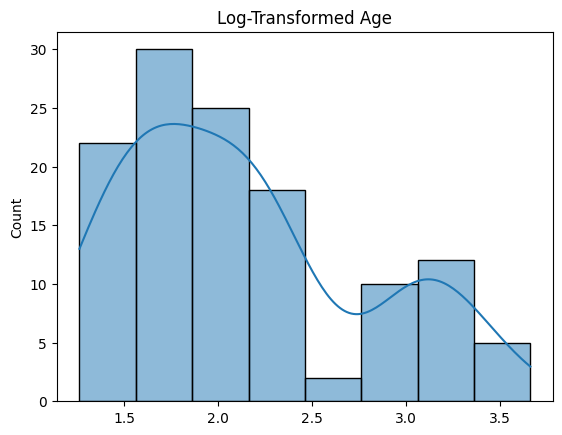

In [102]:
sns.histplot(y_train_log, kde=True)
plt.title("Log-Transformed Age")

Let's the impact of this `preprocessing` step and `cross-validate` our `model` once again with this new `log-transformed target`:

R2: 0.13890582979215949
MAE: 0.46918218095165476


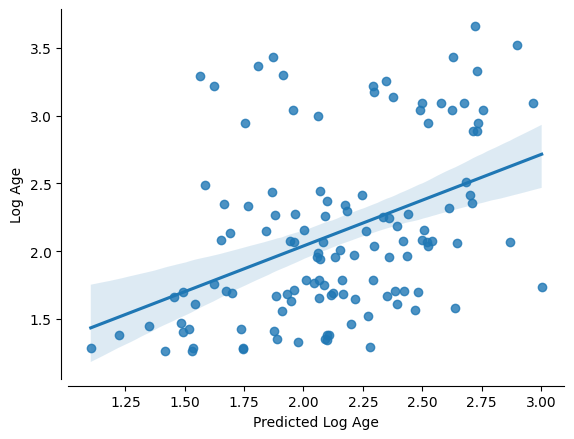

In [105]:
# predict
y_pred = cross_val_predict(l_svr, X_train, y_train_log, cv=10)

# scores
acc = r2_score(y_train_log, y_pred)
mae = mean_absolute_error(y_train_log,y_pred)

print('R2:',acc)
print('MAE:',mae)

sns.regplot(x = y_pred, y = y_train_log)
plt.xlabel('Predicted Log Age')
plt.ylabel('Log Age')
sns.despine(offset=5)

Alrighty, that seems like an improvement as indicated by the `R²` and the `MAE`. However, there's a downside: `normalization` can sometimes reduce `interpretability` because the `transformed` values no longer reflect the original units, which may obscure the direct real-world meaning of the `data`. Therefore, `normalization` is particularly useful when `features` vary widely in `scale` or when `numerical stability` and `model` `performance` are priorities, but if preserving the original `scale` for interpretability is crucial, one might consider transforming the results back to the original units after `modeling`.

Several `normalization` techniques can be used to `scale data` effectively, each with its benefits depending on the `data` characteristics and `modeling` requirements:

- `Min-Max Scaling`: This method `rescales` the `data` to a fixed `range`, typically `[0, 1]`. It's useful when you want to preserve the `shape` of the `original distribution` but adjust the `scale`.
- `Standardization` (`Z-score Scaling`): `Standardization` `transforms` `data` to have a `mean` of `zero` and a `standard deviation` of one. This technique is effective when the `data distribution` is roughly `Gaussian` and you want to compare `features` on a similar `scale`.
- `Robust Scaling`: This approach uses the `median` and interquartile `range`, making it less sensitive to `outliers` than `standardization`.
- `Log Transformation`: By applying a `logarithm`, this transformation reduces the impact of extreme `values` and can help in `normalizing` `skewed data distributions`.
- `Quantile Transformation`: This method maps the original `data` to a uniform or `normal distribution` based on `quantiles`, which can be beneficial when the underlying `distribution` is `non-Gaussian`.
- `Max-Abs Scaling`: This technique `scales data` by its `maximum absolute value`, preserving the `sparsity of data` and ensuring `features` lie within the `range` `[-1, 1]`.
- 
Each of these methods has its own strengths, so the choice should be guided by the specific nature of your `data` and the `requirements` of your modeling approach.

#### Tweak the `hyperparameters`

Many `machine learning` algorithms have `hyperparameters` that can be "tuned" to optimize `model fitting`. `Hyperparameters` are the external configurations set before `training` a `machine learning` `model`. Unlike `model` `parameters` that are `learned` from the `data` during `training`, `hyperparameters` determine how the `learning process` is conducted. They can influence various aspects of the `model`, such as its `complexity`, `learning rate`, or `regularization` strength. Choosing the right `hyperparameters` is crucial because they can significantly impact the `model`’s `performance` and its ability to `generalize` to new, unseen `data`.

Tuning these `hyperparameters` is essential, as careful adjustments can significantly enhance `model performance` and `fit`. However, overly aggressive or unsystematic `tuning` can lead to `overfitting`, where the `model` becomes too tailored to the `training data` and performs poorly on `unseen data`.

For instance, our `Support Vector Regression` (`SVR`) `model` includes several `hyperparameters` such as the `kernel type`, `regularization parameter` (`C`), and `epsilon` value in the `loss function`. Exploring systematic approaches like `grid search`, `random search`, or `Bayesian optimization` can help identify the best combination of `hyperparameters` while mitigating the risk of `overfitting`. These methods allow us to iteratively refine our `model`, balancing `complexity` and `generalization` for optimal `predictive performance`.

In [ ]:
SVR?

One way is to plot a "`Validation Curve`" -- this will let us view changes in `training` and `validation` `accuracy` of a `model` as we shift its `hyperparameters`. We can do this easily with `scikit-learn`. Let's start with the `regulariazation parameter` `C`.

In `Support Vector Regression` (`SVR`), the `hyperparameter C` plays a crucial role as the `regularization parameter`. It controls the `trade-off` between `fit`ting the `training data` well and keeping the `model` as simple as possible. A high value of `C` forces the `model` to `penalize` `errors` more heavily, leading to a closer `fit` to the `training data` but increasing the risk of `overfitting`. Conversely, a lower value of `C` allows more flexibility by tolerating some `errors`, which can help the `model generalize` better to `unseen data`. This balance is key to achieving `optimal performance` in `SVR` and other `models`.

We're going to set a `range` of `C` values and evaluate the impact.

In [107]:
from sklearn.model_selection import validation_curve

C_range = 10. ** np.arange(-3, 8) # A range of different values for C

train_scores, valid_scores = validation_curve(l_svr, X_train, y_train_log, 
                                              param_name= "C",
                                              param_range = C_range,
                                              cv=10)

Nice. With a little bit of `pandas`, we can make the results ready for an informative plot:

In [110]:
tScores = pd.DataFrame(train_scores).stack().reset_index()
tScores.columns = ['C','Fold','Score']
tScores.loc[:,'Type'] = ['Train' for x in range(len(tScores))]

vScores = pd.DataFrame(valid_scores).stack().reset_index()
vScores.columns = ['C','Fold','Score']
vScores.loc[:,'Type'] = ['Validate' for x in range(len(vScores))]

ValCurves = pd.concat([tScores,vScores]).reset_index(drop=True)
ValCurves.head()

,C,Fold,Score,Type
0,0,0,0.163018,Train
1,0,1,0.135617,Train
2,0,2,0.140916,Train
3,0,3,0.163752,Train
4,0,4,0.123096,Train


which we can create with `seaborn`:

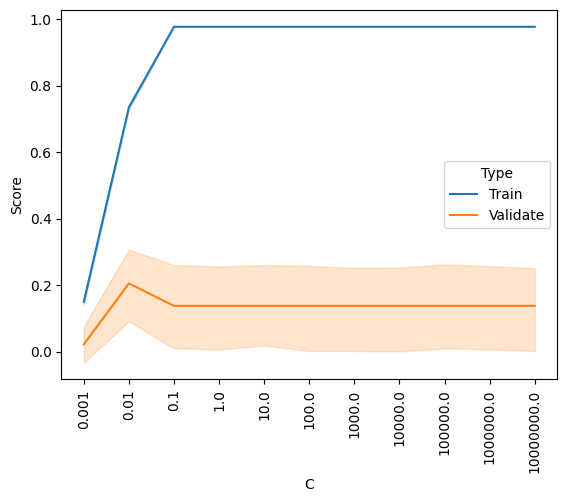

In [116]:
g = sns.lineplot(x='C', y='Score',hue='Type',data=ValCurves)
g.set_xticks(range(11))
g.set_xticklabels(C_range, rotation=90);


It looks like the outcome is better for higher values of `C`, and plateaus somewhere between `0.1` and `1`. The default setting is `C=1`, so it looks like we can't really improve by changing `C`.

But our `SVR` `model` actually has two `hyperparameters`, `C` and `epsilon`. In `SVR`, `epsilon` defines the `margin` of `tolerance` within which no `penalty` is applied to `errors`. Essentially, it creates an "`epsilon-insensitive`" tube around the `predicted` function. `Predictions` that fall within this tube are considered acceptable and do not contribute to the `loss function`. A larger `epsilon` value can make the `model` less sensitive to small deviations, potentially leading to a simpler `model` with better `generalization`. However, setting `epsilon` too high may overlook meaningful `variations` in the `data`, while a very small `epsilon` may result in an overly complex `model` that risks `overfitting`.

Perhaps there is an optimal combination of settings for these two `parameters`.

We can explore that somewhat quickly with a `grid search`, which is once again easily achieved with `scikit-learn`. `Grid search` is a systematic approach to `hyperparameter` tuning that involves exhaustively evaluating a predefined set of `hyperparameter` values. By constructing a "`grid`" of possible combinations, it tests each combination through `cross-validation` to determine which set yields the best `model performance`. While `grid search` can be computationally intensive, it provides a thorough exploration of the `hyperparameter space`, ensuring that the optimal settings are identified for the `model`.

Because we are `fit`ting the `model` multiple times with `cross-validation`, this will take some time.

In [117]:
from sklearn.model_selection import GridSearchCV

C_range = 10. ** np.arange(-3, 8)
epsilon_range = 10. ** np.arange(-3, 8)

param_grid = dict(epsilon=epsilon_range, C=C_range)

grid = GridSearchCV(l_svr, param_grid=param_grid, cv=10)

grid.fit(X_train, y_train_log)

GridSearchCV(cv=10, estimator=SVR(kernel='linear'),
             param_grid={'C': array([1.e-03, 1.e-02, 1.e-01, 1.e+00, 1.e+01, 1.e+02, 1.e+03, 1.e+04,
       1.e+05, 1.e+06, 1.e+07]),
                         'epsilon': array([1.e-03, 1.e-02, 1.e-01, 1.e+00, 1.e+01, 1.e+02, 1.e+03, 1.e+04,
       1.e+05, 1.e+06, 1.e+07])})

Now that the `grid search` has completed, let's find out the "best" `parameter` combination

In [118]:
print(grid.best_params_)

{'C': 0.01, 'epsilon': 0.1}


And if redo our `cross-validation` with this `parameter` set?

R2: 0.13890582979215949
MAE: 0.46918218095165476


Text(0, 0.5, 'Log Age')

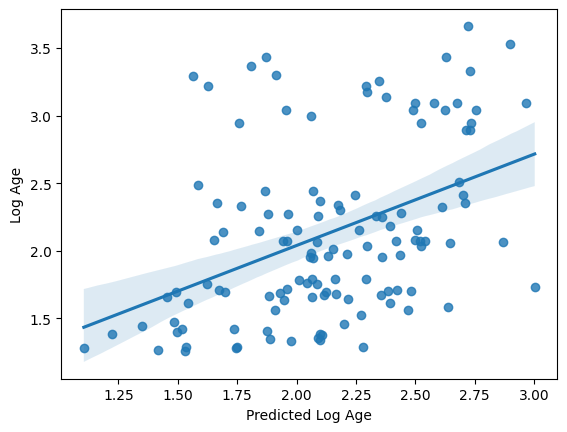

In [120]:
y_pred = cross_val_predict(SVR(kernel='linear',C=0.10,epsilon=0.10, gamma='auto'), 
                           X_train, y_train_log, cv=10)

# scores
acc = r2_score(y_train_log, y_pred)
mae = mean_absolute_error(y_train_log,y_pred)

print('R2:',acc)
print('MAE:',mae)

sns.regplot(x = y_pred, y = y_train_log)
plt.xlabel('Predicted Log Age')
plt.ylabel('Log Age')

Perhaps unsurprisingly, the `model fit` is actually exactly the same as what we had with our defaults. 

`Grid search` can be a powerful and useful tool. But can you think of a way that, if not properly utilized, it could lead to `overfitting`?

You can find a nice set of tutorials with links to very helpful content regarding how to tune `hyperparameters` while be aware of `over`- and `under-fitting` here:
https://scikit-learn.org/stable/modules/learning_curve.html

#### Trying a more complicated model

While a simple `linear model` often suffices, experimenting with a more `complex model` can be informative. For instance, although the `data` may not support a very `complex non-linear` relationship (like `high-order polynomials`) due to limited `sample size`, exploring these options can reveal potential trends, such as a `quadratic relationship` with `age`. For demonstration purposes, we'll use a `validation curve` to assess how the `model`'s `performance` changes as we increase the `polynomial degree` from `2nd` to `8th order`. This approach helps us visualize whether adding complexity improves `predictions` or leads to `overfitting`.

In [121]:
from sklearn.model_selection import validation_curve

degree_range = list(range(1,8)) # A range of different values for C

train_scores, valid_scores = validation_curve(SVR(kernel='poly',
                                                  gamma='scale'
                                                 ), 
                                              X=X_train, y=y_train_log, 
                                              param_name= "degree",
                                              param_range = degree_range,
                                              cv=10)


Nice. With a little bit of `pandas`, we can make the results ready for an informative plot:

In [122]:
tScores = pd.DataFrame(train_scores).stack().reset_index()
tScores.columns = ['Degree','Fold','Score']
tScores.loc[:,'Type'] = ['Train' for x in range(len(tScores))]

vScores = pd.DataFrame(valid_scores).stack().reset_index()
vScores.columns = ['Degree','Fold','Score']
vScores.loc[:,'Type'] = ['Validate' for x in range(len(vScores))]

ValCurves = pd.concat([tScores,vScores]).reset_index(drop=True)
ValCurves.head()

,Degree,Fold,Score,Type
0,0,0,0.829687,Train
1,0,1,0.818176,Train
2,0,2,0.807175,Train
3,0,3,0.808440,Train
4,0,4,0.809553,Train


which we can create with `seaborn`:

[Text(0, 0, '1'),
 Text(1, 0, '2'),
 Text(2, 0, '3'),
 Text(3, 0, '4'),
 Text(4, 0, '5'),
 Text(5, 0, '6'),
 Text(6, 0, '7')]

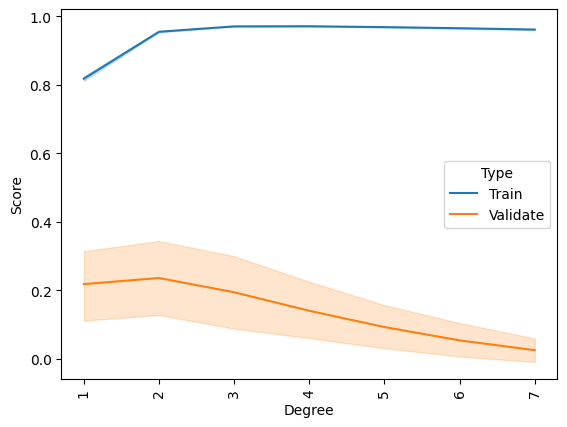

In [123]:
g = sns.lineplot(x='Degree',y='Score',hue='Type',data=ValCurves)
g.set_xticks(range(7))
g.set_xticklabels(degree_range, rotation=90)

It appears that we cannot improve our `model` by increasing the `complexity` of the `fit`. If one looked only at the `training data`, one might surmise that a `2nd order fit` could be a slightly better `model` but that improvement does not `generalize` to the `validation data`.

#### Feature selection

With `741 features`, it's unlikely that every single one contributes stably to the `model`. Generally, `models` perform better when they are built on a smaller `set` of important `features` rather than a vast number of less relevant ones. The challenge lies in identifying which `features` are truly useful. To address this, we'll implement a basic `feature selection` strategy to sift through the `features` and retain only those that provide a certain `predictive value`.

In [125]:
X_train.shape

(124, 741)

We can use `scikit-learn`'s [SelectPercentile()]() function which selects the top `X%` of `features` based on `univariate tests`, aiming to identify those with the highest potential relevance. This approach helps highlight theoretically useful `features`, but it's important to remember that `statistical significance` does not always translate to `predictive power`. 

Additionally, there is a risk of `overfitting`. For example, when using `10-fold cross-validation`, separate `feature selection` must be performed within each `fold`. This requirement means that a manual `cross-validation` setup is necessary rather than relying on automated functions like `cross_val_predict()`.

In [126]:
from sklearn.feature_selection import SelectPercentile, f_regression
from sklearn.model_selection import KFold
from sklearn.pipeline import Pipeline

# Build a tiny pipeline that does feature selection (top 20% of features), 
# and then prediction with our linear svr model.
model = Pipeline([
    ('feature_selection',SelectPercentile(f_regression,percentile=20)),
    ('prediction', l_svr)
                 ])

y_pred = [] # a container to catch the predictions from each fold
y_index = [] # just in case, the index for each prediciton

# First we create 10 splits of the data
skf = KFold(n_splits=10, shuffle=True, random_state=123)

# For each split, assemble the train and test samples 
for tr_ind, te_ind in skf.split(X_train):
    X_tr = X_train[tr_ind]
    y_tr = y_train_log[tr_ind]
    X_te = X_train[te_ind]
    y_index += list(te_ind) # store the index of samples to predict
    
    # and run our pipeline 
    model.fit(X_tr, y_tr) # fit the data to the model using our mini pipeline
    predictions = model.predict(X_te).tolist() # get the predictions for this fold
    y_pred += predictions # add them to the list of predictions

Alrighty, let's see if only using the top `20%` of `features` improves the `model` at all.

R2: -0.23181012383026856
MAE: 0.5460803399486623


Text(0, 0.5, 'Log Age')

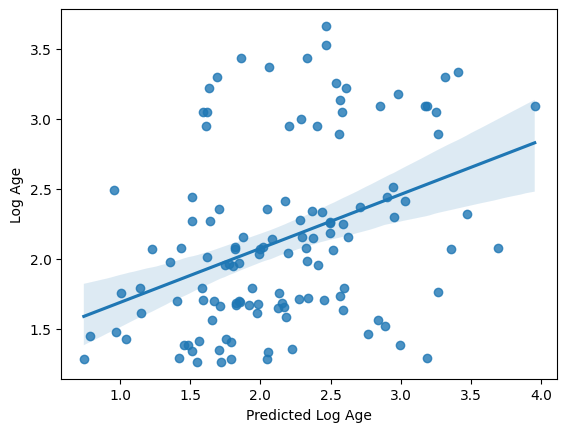

In [128]:
acc = r2_score(y_train_log[y_index], y_pred)
mae = mean_absolute_error(y_train_log[y_index],y_pred)

print('R2:',acc)
print('MAE:',mae)

sns.regplot(x = np.array(y_pred), y = y_train_log[y_index])
plt.xlabel('Predicted Log Age')
plt.ylabel('Log Age')


Nope, in fact it got a bit worse. It seems we're getting "value at the margins" so to speak. This is a very good example of how significance != prediction.

For more details on the variety of `feature selection` techniques available in `scikit-learn`, refer to the [scikit-learn documentation](https://scikit-learn.org/stable/modules/feature_selection.html). Additionally, this [DataCamp tutorial](https://www.datacamp.com/community/tutorials/feature-selection-python) offers a thoughtful introduction to `feature selection` for new `machine learning` practitioners.

In summary, while we experimented with several `feature selection` and `model` tweaking strategies, most adjustments didn't lead to notable improvements in performance — a common outcome in practice. There could be several reasons for this, including the possibility that our original `feature set` was already well-suited to the problem or that further tweaks might simply overcomplicate the `model` without adding `predictive value`. As we move forward with our `validation data`, it might be best to stick with a more basic `model`, though exploring options like `predicting` `log-transformed age` could be worthwhile.

## Can our model predict age in completely un-seen data?

Having developed a `model` to `predict` `age` from `rs-fMRI`, ie `functional connectome`s, it's time to assess its `generalizability`. We'll retrain our `model` using the entire `training dataset` and then evaluate its `performance` by `predicting` the `age` of participants, ie `samples` (`n`) that were set aside in the `test set` at the beginning. This step is crucial to determine if our `model` can accurately `predict` `age` in completely new, `unseen data`.

Because we performed a `log transformation` on our `training data`, we will need to `transform` our testing data using the same information. This consistency ensures that the `model` interprets the `test data` in the same way it learned from the `training data`. Fortunately, since we stored our `transformation` in an object, we can easily reuse it, guaranteeing that both `datasets` are processed identically.

In [129]:
y_test_log = log_transformer.transform(y_test.values.reshape(-1,1))[:,0]

And now for the moment of truth! 

No cross-validation needed here. We simply fit the model with the training data and use it to predict the testing data

I'm so nervous. Let's just do it all in one cell

In [142]:
import warnings
warnings.filterwarnings("ignore")

from sklearn.compose import TransformedTargetRegressor

# Define the log transformer
# To invert the transformation and predict on the original scale, set inverse_func=np.exp
log_transformer = FunctionTransformer(np.log, validate=True, check_inverse=False)

# Create a TransformedTargetRegressor that applies the log transformation to the target
# Here, l_svr is your SVR model
model_pipeline = TransformedTargetRegressor(regressor=l_svr, transformer=log_transformer)

# Fit the pipeline on all of the training data
model_pipeline.fit(X_train, y_train.values)

# Evaluate performance using cross-validation on the training set
# This returns predictions on the log-transformed scale (if no inverse_func is set)
y_train_log = log_transformer.transform(y_train.values.reshape(-1, 1))[:, 0]
y_pred_cv = cross_val_predict(model_pipeline, X_train, y_train.values, cv=10)


Ok, let's check the `performance` as we usually do.

In [143]:
acc = r2_score(y_train_log, y_pred_cv)
mae = mean_absolute_error(y_train_log, y_pred_cv)

print('R2:', acc)
print('MAE:', mae)

R2: 0.13890582979215949
MAE: 0.46918218095165476


The same as we got before, ok. Now it's time to evaluate our `model`'s `performance` on the so-far unseen `test data`. To do so, we use the `fit`ted `model` (in this case the `pipeline` that entails the `transformation` and the `model`) to `predict` `age` in the `test sample`, `X_test`

In [144]:
y_pred_test = model_pipeline.predict(X_test)

and then compute its `performance` as we did before.

In [145]:
# Evaluate on the testing set
# Transform the true test targets to log scale for comparison
y_test_log = log_transformer.transform(y_test.values.reshape(-1, 1))[:, 0]

test_acc = r2_score(y_test_log, y_pred_test)
test_mae = mean_absolute_error(y_test_log, y_pred_test)

print('Test R2:', test_acc)
print('Test MAE:', test_mae)

Test R2: 0.28118555453590877
Test MAE: 0.39670454186692794


It got slightly worse but not terribly worse. Let's plot the `predicted` against the `actual` `age` again.

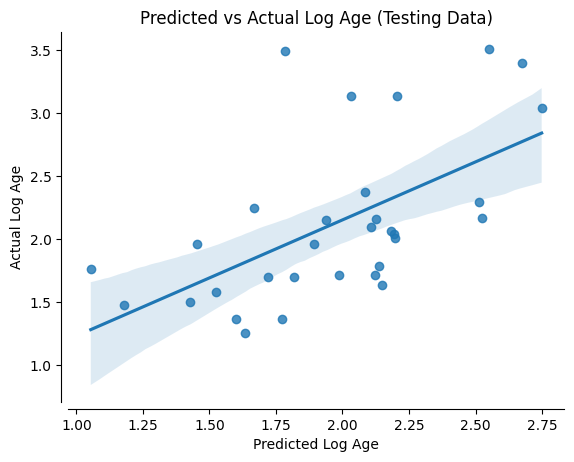

In [146]:
sns.regplot(x=y_pred_test, y=y_test_log)
plt.xlabel('Predicted Log Age')
plt.ylabel('Actual Log Age')
plt.title("Predicted vs Actual Log Age (Testing Data)")
sns.despine(offset=5)
plt.show()

Alright, somewhat as expected given the `performance` values above. 

While the `model` and `pipelines` we used appear to be not really working in terms of `predicting` our `target data`, ie `age` based on `functional connectomes`, we at least see a stable `performance` when applied to the `test data`. However, of course the question would be: Is this model "usefull"? Overall, it might not be the best idea to employ this `model` in the wild given its `performance`. 

There are many possible reasons why this could be the case, from all the aspects we explored here (and the many more we did not had the time to go through) to the underlying data.

To outline this and vast landscape of options you have to define and run `machine learning` analyzes, we will:

- use a different `learning problem` -> instead of `predicting` the `continuous` `target` `age`, we will try to predict a `categorical` `target`, here `Child_Adult`, indicating if `participants` were `children` or `adults`
- not do any `adaptation` -> no `preprocessing`, `hyperparameter tuning` or `feature selection`
- apply the `model` to all `functional connectome` types we computed before -> `correlation`, `partial correlation`, `tangent`

and in the end compare the outcome qualitatively.

To do that, we initially have to load all previously `computed` `functional connectomes`.

In [150]:
X_features_cor = np.load('data/development_fmri_correlation_matrix.npz', allow_pickle=True)['correlation_matrices']

features_unique = []

for i, matrix in enumerate(X_features_cor):

    features_unique_tmp = connectome.sym_matrix_to_vec(matrix, discard_diagonal=True)

    features_unique.append(features_unique_tmp)

X_features_cor = np.array(features_unique)

In [151]:
X_features_par_cor = np.load('data/development_fmri_partial_correlation_matrix.npz', allow_pickle=True)['partial_correlation_matrices']

features_unique = []

for i, matrix in enumerate(X_features_par_cor):

    features_unique_tmp = connectome.sym_matrix_to_vec(matrix, discard_diagonal=True)

    features_unique.append(features_unique_tmp)

X_features_par_cor = np.array(features_unique)

In [152]:

X_features_tan = np.load('data/development_fmri_tangent_matrix.npz', allow_pickle=True)['tangent_matrices']

features_unique = []

for i, matrix in enumerate(X_features_tan):

    features_unique_tmp = connectome.sym_matrix_to_vec(matrix, discard_diagonal=True)

    features_unique.append(features_unique_tmp)

X_features_tan = np.array(features_unique)

Next, we are going to get and assign our new `target`, this time two `classes`: `Child` or `Adult`.

In [157]:
groups = demographic_info['Child_Adult']
_, classes = np.unique(groups, return_inverse=True)

We then define all `functional connectome` types

In [158]:
kinds = ["correlation", "partial correlation", "tangent"]

and create a new `cross-validatio` strategy with `15 splits` and a `test_size` of `5`, as well as the `participants`, ie our `samples` (`n`) we want to `split` into `training` and `test data`.

In [159]:
from sklearn.model_selection import StratifiedShuffleSplit

cv = StratifiedShuffleSplit(n_splits=15, random_state=0, test_size=5)
pooled_subjects = np.asarray(demographic_info['participant_id'])


Having everything in place, we can run the `model`, looping over the different `functional connectome` types and storing the respective outcomes, that is `performance`.

In [169]:
from sklearn.metrics import accuracy_score
from sklearn.svm import LinearSVC

scores = {}
for kind in kinds:
    scores[kind] = []
    for train, test in cv.split(pooled_subjects, classes):

        if kind == 'correlation':

                # fit the classifier
                classifier = LinearSVC(dual=True).fit(X_features_cor[train], classes[train])
            
                # make predictions for the left-out test subjects
                predictions = classifier.predict(X_features_cor[test]
                )
            
                # store the accuracy for this cross-validation fold
                scores[kind].append(accuracy_score(classes[test], predictions))

        if kind == 'partial correlation':

                # fit the classifier
                classifier = LinearSVC(dual=True).fit(X_features_par_cor[train], classes[train])
            
                # make predictions for the left-out test subjects
                predictions = classifier.predict(X_features_par_cor[test]
                )
            
                # store the accuracy for this cross-validation fold
                scores[kind].append(accuracy_score(classes[test], predictions))

        if kind == 'tangent':

                # fit the classifier
                classifier = LinearSVC(dual=True).fit(X_features_tan[train], classes[train])
            
                # make predictions for the left-out test subjects
                predictions = classifier.predict(X_features_tan[test]
                )
            
                # store the accuracy for this cross-validation fold
                scores[kind].append(accuracy_score(classes[test], predictions))
        

Great. Now we can compute the `mean scores` and `score std` for each `input`, `X`, ie `functional connectome` type

In [170]:
mean_scores = [np.mean(scores[kind]) for kind in kinds]
scores_std = [np.std(scores[kind]) for kind in kinds]

and check them:

In [171]:
mean_scores

[0.7733333333333335, 0.7866666666666668, 0.8133333333333336]

In [176]:
scores_std

[0.12364824660660939, 0.08844332774281068, 0.04988876515698587]

However, in order to get a better understanding of the `performance` of our `model` based on the different `input`s, `X`, ie `functional connectomes`, we will create a little graphic plotting the respective values, also indicating `chance level`.

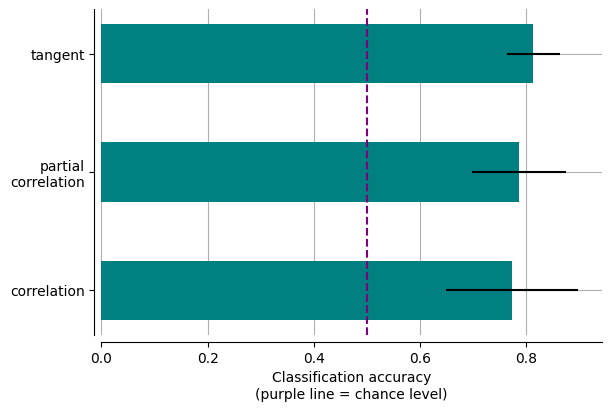

In [177]:
plt.figure(figsize=(6, 4), constrained_layout=True)

positions = np.arange(len(kinds)) * 0.1 + 0.1
plt.barh(positions, mean_scores, align="center", height=0.05, xerr=scores_std, color='teal')
yticks = [k.replace(" ", "\n") for k in kinds]
plt.yticks(positions, yticks)
plt.gca().grid(True)
plt.gca().set_axisbelow(True)
plt.gca().axvline(0.5, color="purple", linestyle="--")
plt.xlabel("Classification accuracy\n(purple line = chance level)")
sns.despine(offset=5)